# Airbnb Data Analysis


###      STEP 1: Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### STEP 2: Loading the Dataset

In [2]:
df = pd.read_csv("compressed_data.csv")
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns") # df.shape = returns a tuple in the form of (rows,columns)

✅ Dataset loaded successfully!
Shape: 102599 rows × 26 columns


### STEP 3: Data Exploration

In [3]:
# First 5 rows
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.columns.tolist()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

### STEP 4: Checking & Handling Missing Values

In [5]:
# df.isnull() this will give us the TRUE FALSE value for each row and column
df.isnull().sum() # it will just summarise and count the null values for each column

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
df.columns.tolist()

['id',
 'NAME',
 'host id',
 'host_identity_verified',
 'host name',
 'neighbourhood group',
 'neighbourhood',
 'lat',
 'long',
 'country',
 'country code',
 'instant_bookable',
 'cancellation_policy',
 'room type',
 'Construction year',
 'price',
 'service fee',
 'minimum nights',
 'number of reviews',
 'last review',
 'reviews per month',
 'review rate number',
 'calculated host listings count',
 'availability 365',
 'house_rules',
 'license']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [8]:
# Here we can see 'last review' column's datatype is 'object'
# Whereas the data present inside that column is in format of Date-Time
# So we have to change the datatype of this column
df['last review'] = pd.to_datetime(df['last review'], errors = 'coerce')
df['last review'].dtype

dtype('<M8[ns]')

### Handling Missing Values

- Filled missing values in **`reviews per month`** with **0**, indicating that the listing has no recorded reviews.
- Filled missing values in **`last review`** with the **earliest available review date** (`min()`), ensuring the column contains valid datetime values.

In [9]:
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace = True)

### Removing Rows which contain Missing Values in the Column 'NAME' and 'host name'

In [10]:
df.dropna(subset=['NAME', 'host name'], inplace=True)

In [11]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

### Removing Columns 'house_rules' and 'license' which contains many null values

In [12]:
# Since columns such as 'house_rules' and 'license' have too many null values
# So that we can drop them.
df = df.drop(['house_rules', 'license'], axis=1)

### Cleaning Price and Service Fee Columns

- Removed special characters (`$` and `,`) from the **`price`** and **`service fee`** columns using regular expressions.
- Converted both columns from **string (`object`)** to **`float`** data type to enable numerical calculations and analysis.

In [13]:
df['price'] = df['price'].replace('[\$,]', '', regex = True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex = True).astype(float)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101949 entries, 0 to 102598
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101949 non-null  int64         
 1   NAME                            101949 non-null  object        
 2   host id                         101949 non-null  int64         
 3   host_identity_verified          101673 non-null  object        
 4   host name                       101949 non-null  object        
 5   neighbourhood group             101923 non-null  object        
 6   neighbourhood                   101933 non-null  object        
 7   lat                             101941 non-null  float64       
 8   long                            101941 non-null  float64       
 9   country                         101423 non-null  object        
 10  country code                    101827 non-null  object      

### Removing Duplicate Records

- Removed duplicate rows from the dataset to ensure each observation is unique.
- By default, `drop_duplicates()` keeps the first occurrence of each duplicate row and removes the remaining duplicates.

In [15]:
df = df.drop_duplicates()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

In [17]:
# Check if there are any duplicate rows
df.duplicated().any()

np.False_

### Descriptive Statistics

The `describe()` function provides a statistical summary of the dataset. For numerical columns, it returns key statistics such as:

- **Count** – Number of non-null values
- **Mean** – Average value
- **Standard Deviation (`std`)** – Measure of data dispersion
- **Minimum (`min`)** – Smallest value
- **25%, 50%, 75%** – Quartiles (Q1, Median, and Q3)
- **Maximum (`max`)** – Largest value

These statistics help in understanding the distribution, central tendency, and spread of the data.

In [18]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.014100e+05,1.014100e+05,101402.000000,101402.000000,101210.000000,101171.000000,101142.000000,101016.000000,101228.000000,101410,101410.000000,101103.000000,101092.000000,100990.000000
mean,2.920959e+07,4.926155e+10,40.728082,-73.949663,2012.486908,625.381008,125.043998,8.113744,27.511854,2018-05-15 21:26:08.721033728,1.163207,3.278558,7.948463,141.164660
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.507574e+07,2.459183e+10,40.688730,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-30 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.922911e+07,4.912069e+10,40.722300,-73.954440,2012.000000,625.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,96.000000
75%,4.328308e+07,7.399747e+10,40.762750,-73.932340,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.626820e+07,2.853703e+10,0.055850,0.049474,5.765130,331.609111,66.313374,30.378014,49.549258,NaN,1.683708,1.285369,32.328974,135.419199


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   NAME                            101410 non-null  object        
 2   host id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  object        
 4   host name                       101410 non-null  object        
 5   neighbourhood group             101384 non-null  object        
 6   neighbourhood                   101394 non-null  object        
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  object        
 10  country code                    101288 non-null  object      

### STEP 5: Visualization

#### Q. What is the distribution of listing prices?

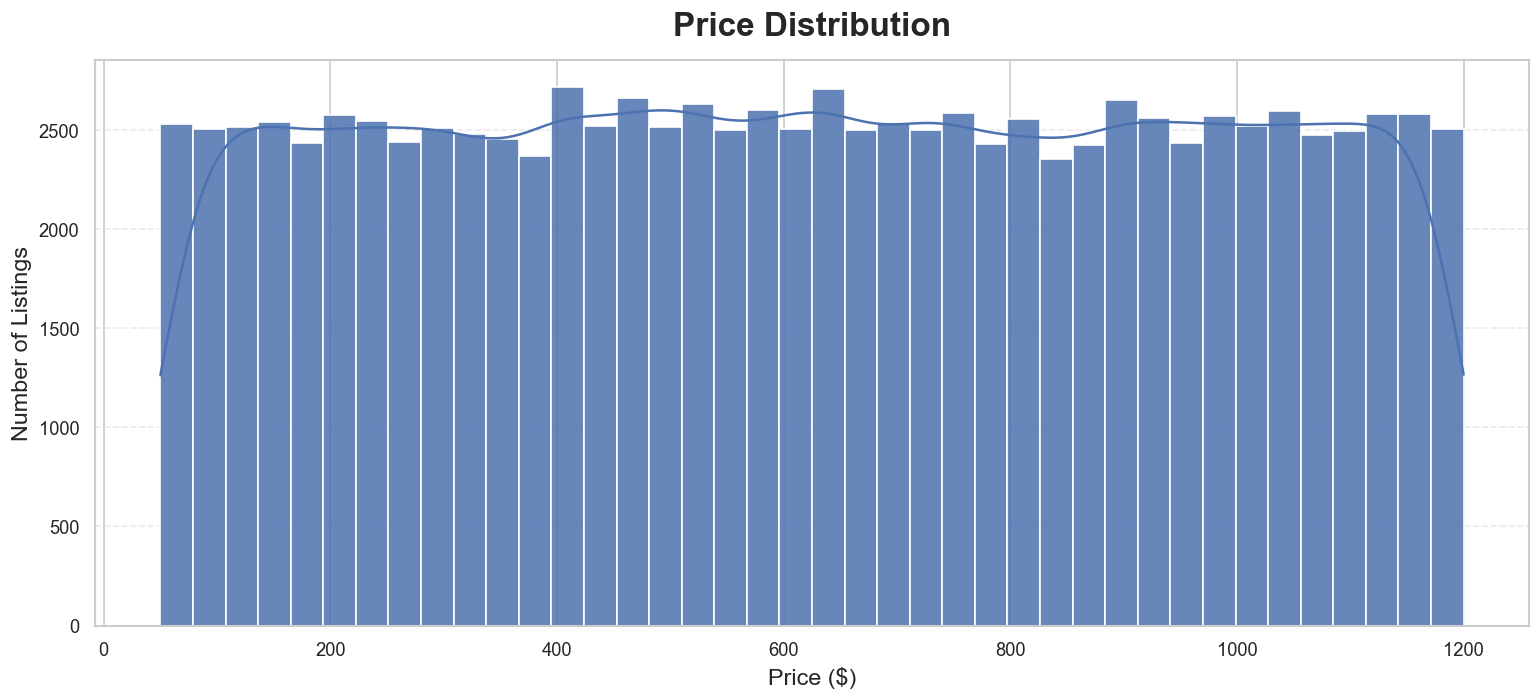

In [28]:
sns.set_theme(style="whitegrid", palette="deep")

plt.figure(figsize=(13,6), dpi=120)

ax = sns.histplot(
    df['price'],
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="white",
    linewidth=1,
    alpha=0.85
)

ax.set_title("Price Distribution", fontsize=20, fontweight="bold", pad=15)
ax.set_xlabel("Price ($)", fontsize=14)
ax.set_ylabel("Number of Listings", fontsize=14)

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

#### 📌 Key Insights from the Price Distribution

- **`Uniform Distribution:`** The prices are distributed almost uniformly across the entire range, indicating that listings are fairly evenly spread among different price levels.

- **`No Significant Skewness:`** The distribution is approximately symmetric, with no noticeable left or right skew, suggesting the absence of a strong bias toward lower or higher prices.

- **`No Dominant Price Range:`** The histogram and KDE curve do not show a distinct peak, indicating that no single price range contains a significantly higher number of listings.

- **`Wide Range of Prices:`** Listing prices span a broad range (approximately **\$50–\$1200**), reflecting substantial diversity in pricing across the dataset.

#### Q. How are different room types distributed?

In [30]:
df['room type']

0            Private room
1         Entire home/apt
2            Private room
4         Entire home/apt
5         Entire home/apt
               ...       
102053       Private room
102054       Private room
102055    Entire home/apt
102056       Private room
102057    Entire home/apt
Name: room type, Length: 101410, dtype: object

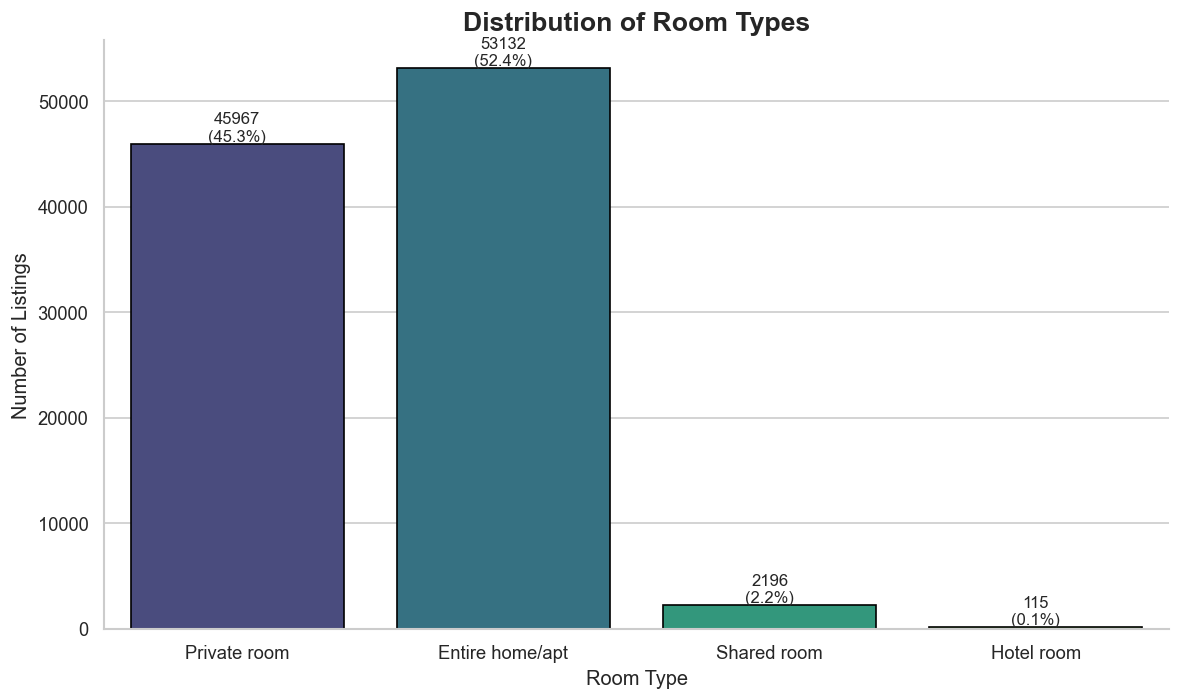

In [37]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6), dpi=120)

ax = sns.countplot(
    data=df,
    x='room type',
    palette='viridis',
    edgecolor='black'
)

total = len(df)

# I loop through each bar in the chart, 
# calculate its count and percentage, and use ax.annotate() to display those values above the bars for better readability
for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Room Types", fontsize=16, fontweight='bold')
plt.xlabel("Room Type", fontsize=12)
plt.ylabel("Number of Listings", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

#### 📌 Key Insights from the Distribution of Room Types

- **`Entire home/apartment is the most common room type`**, accounting for **`53,132 listings (52.4%)`**, indicating that more than half of all listings offer the entire property to guests.

- **`Private rooms make up a significant share`** with **`45,967 listings (45.3%)`**, showing that private accommodations are also highly popular among hosts.

- **`Shared rooms and hotel rooms are relatively rare`**, contributing only **`2.2%`** and **`0.1%`** of the total listings, respectively.

- **`The dataset is dominated by two room type`s**—**`Entire home/apartment`** and **`Private room`**—which together represent **`over 97%`** of all listings, while the remaining room types have minimal representation.

#### Q. How are listings distributed across different neighbourhoods?

In [38]:
df['neighbourhood group']

0          Brooklyn
1         Manhattan
2         Manhattan
4         Manhattan
5         Manhattan
            ...    
102053     Brooklyn
102054     Brooklyn
102055     Brooklyn
102056    Manhattan
102057    Manhattan
Name: neighbourhood group, Length: 101410, dtype: object

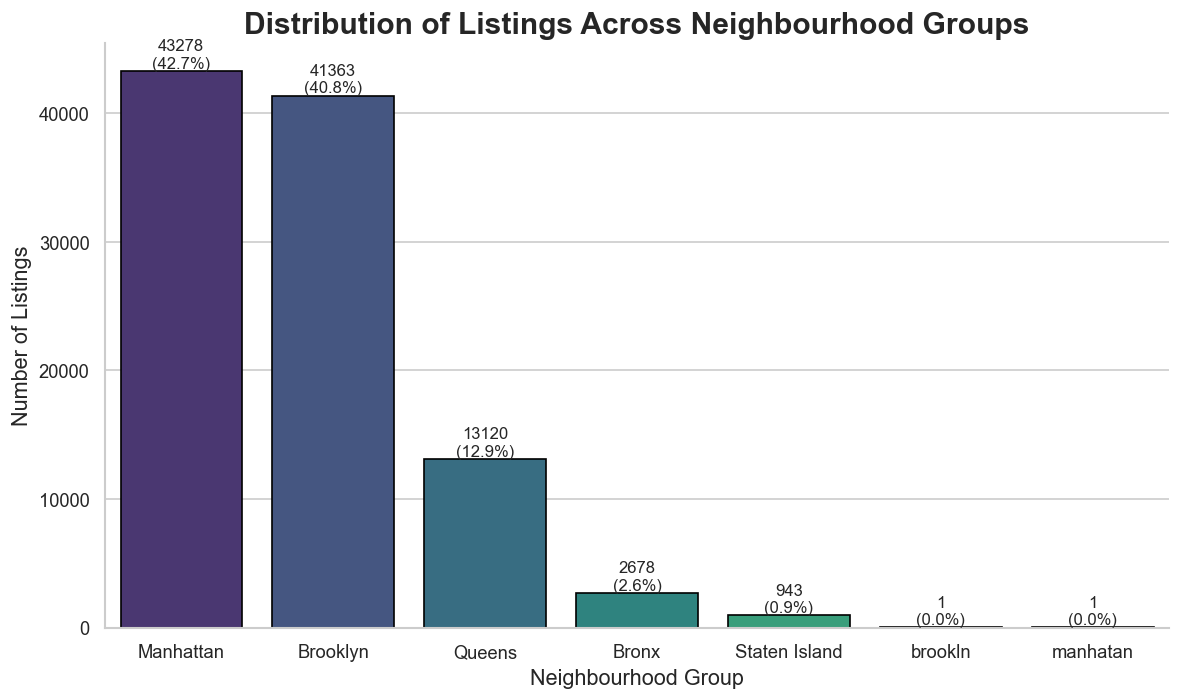

In [39]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6), dpi=120)

order = df['neighbourhood group'].value_counts().index

ax = sns.countplot(data=df, x='neighbourhood group', order=order, palette='viridis', edgecolor='black')

total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.1f}%)',
        (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom', fontsize=10)

plt.title("Distribution of Listings Across Neighbourhood Groups", fontsize=18, fontweight='bold')

plt.xlabel("Neighbourhood Group", fontsize=13)
plt.ylabel("Number of Listings", fontsize=13)

sns.despine()
plt.tight_layout()
plt.show()

#### 📌 Key Insights from the Distribution of Listings Across Neighbourhood Groups

- **`Manhattan has the highest number of listings`**, with **`43,278 listings (42.7%)`**, making it the most popular neighbourhood group in the dataset.

- **`Brooklyn closely follows Manhattan`**, contributing **`41,363 listings (40.8%)`**. Together, **`Manhattan and Brooklyn account for over 83% of all listings`**, indicating that Airbnb listings are heavily concentrated in these two boroughs.

- **`Queens has a moderate presence`** with **`13,120 listings (12.9%)`**, while **`Bronx (2.6%)`** and **`Staten Island (0.9%)`** have relatively few listings, suggesting lower Airbnb activity in these areas.

#### Q. What is the relationship between price and room type?

In [41]:
df[['price','room type']]

,price,room type
0,966.0,Private room
1,142.0,Entire home/apt
2,620.0,Private room
4,204.0,Entire home/apt
5,577.0,Entire home/apt
...,...,...
102053,696.0,Private room
102054,909.0,Private room
102055,387.0,Entire home/apt
102056,848.0,Private room


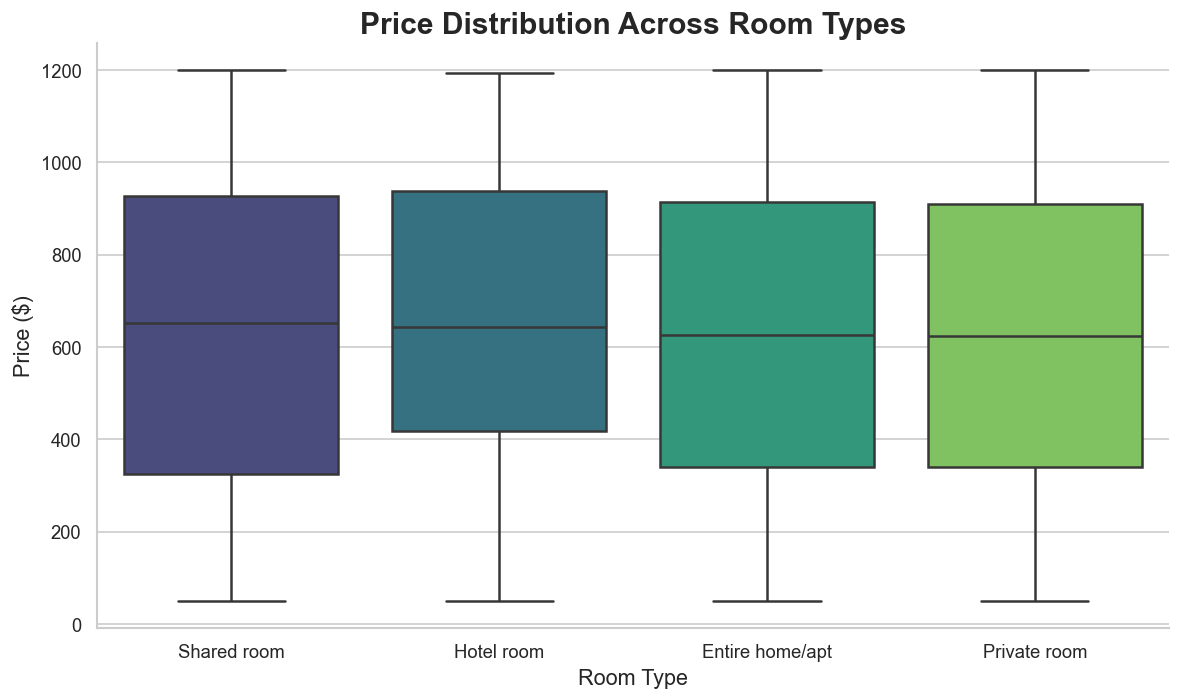

In [42]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6), dpi=120)

order = df.groupby('room type')['price'].median().sort_values(ascending=False).index

ax = sns.boxplot(data=df, x='room type', y='price', order=order, palette='viridis', linewidth=1.5, showfliers=False)

plt.title("Price Distribution Across Room Types", fontsize=18, fontweight='bold')

plt.xlabel("Room Type", fontsize=13)
plt.ylabel("Price ($)", fontsize=13)

sns.despine()

plt.tight_layout()
plt.show()

#### 📌 Key Insights from the Price Distribution Across Room Types

- **`Median prices are very similar across all room types`**, indicating that there is no significant difference in the typical listing price based on room type.

- **`The price spread (variability) is nearly identical`** for all room types, suggesting that prices are distributed similarly regardless of the accommodation type.

- **`Each room type covers a wide price range`**, with listings ranging from approximately **\$50 to \$1200**, indicating substantial price variation within every category.

- **`No room type consistently appears more expensive or cheaper`** than the others, as the boxplots largely overlap in terms of median, interquartile range (IQR), and overall spread.

- **`No significant outliers are displayed`** because the visualization was created using `showfliers=False`, which hides extreme values for a cleaner comparison.